Chart saved to figures/color_cumulative_vicuna_jbb_finetune.pdf


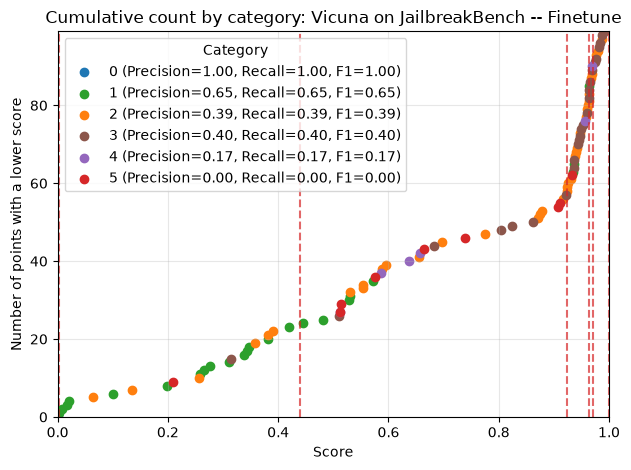

<Axes: title={'center': 'Cumulative count by category: Vicuna on JailbreakBench -- Finetune'}, xlabel='Score', ylabel='Number of points with a lower score'>

In [ ]:
## Riding labels
import json
from pprint import pprint

import handlabel_utils as hutil
import visualisation_utils as vutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Naming logic
model = "Vicuna"
dataset_name = "JailbreakBench"

## Automatic evaluation load
evaluation_method = "finetune"
##Plot naming
save_path = f"{model.lower()}_{dataset_suffix}_{evaluation_method}.pdf"
plot_title = f"{model} on {dataset} -- {evaluation_method.capitalize()}"

## Compute and plot
#vutil.cumulative(scores, quantiles=quantiles, save_path=save_path, plot_title=plot_title)
#hutil.cumulative_frequency_chart(frequencies=handlabel_frequencies)
hutil.color_cumulative(model = model, dataset_name = dataset_name, evaluation_method = evaluation_method, compute_quantiles=True)

Chart saved to figures/color_cumulative_vicuna_jbb_finetune_average_quantiles.pdf


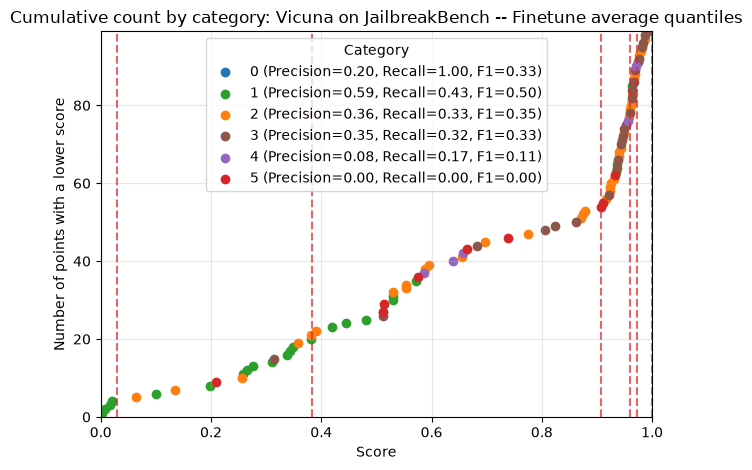

<Axes: title={'center': 'Cumulative count by category: Vicuna on JailbreakBench -- Finetune average quantiles'}, xlabel='Score', ylabel='Number of points with a lower score'>

In [ ]:
## Riding labels
import json
from pprint import pprint

import handlabel_utils as hutil
import visualisation_utils as vutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

handlabel_file = "/home/oscar/strong_reject/handlabeling/project-6-at-2026-09-23-12-15-af564431.json"
with open(handlabel_file, "r", encoding="utf-8") as f:
    labels = json.load(f)

##Naming logic
model = "Vicuna"
dataset = "JailbreakBench"
dataset_suffix = vutil.dataset_suffix_dictionary.get(dataset.lower(), dataset.lower())
handlabel_file_names_llama2 = [f"llama2_{dataset_suffix}_ls.json"]
handlabel_file_names_vicuna = [f"vicuna_{dataset_suffix}_ls.json"]


##Filter handlabels for corresponding model and dataset
matching_experiments_llama2 = hutil.filter_experiment(labels, handlabel_file_names_llama2)
matching_experiments_vicuna = hutil.filter_experiment(labels, handlabel_file_names_vicuna)
handlabel_frequencies_llama2 = hutil.compute_frequencies(matching_experiments_llama2)
handlabel_frequencies_vicuna = hutil.compute_frequencies(matching_experiments_vicuna)

## Automatic evaluation load
results_root = "/home/oscar/strong_reject/results"
evaluation_method = "finetune"


exp_key_llama2 = f"llama2_jbb_{evaluation_method.lower()}"
exp_key_vicuna = f"vicuna_jbb_{evaluation_method.lower()}"
evaluation_file_llama2 = vutil.latest_evaluation_file(results_root, exp_key_llama2)
evaluation_file_vicuna = vutil.latest_evaluation_file(results_root, exp_key_vicuna)
evaluations_llama2 = pd.read_csv(evaluation_file_llama2)
evaluations_vicuna = pd.read_csv(evaluation_file_vicuna)

##Plot naming
save_path = f"{model.lower()}_{dataset_suffix}_{evaluation_method}_average_quantiles.pdf"
plot_title = f"{model} on {dataset} -- {evaluation_method.capitalize()} average quantiles"

## Compute and plot
scores_llama2= evaluations_llama2["score"].values
scores_vicuna= evaluations_vicuna["score"].values
quantiles_llama2= vutil.compute_quantiles(scores_llama2, handlabel_frequencies_llama2)
quantiles_vicuna= vutil.compute_quantiles(scores_vicuna, handlabel_frequencies_vicuna)
quantiles_average = (quantiles_llama2 + quantiles_vicuna) / 2
#vutil.cumulative(scores, quantiles=quantiles, save_path=save_path, plot_title=plot_title)
#hutil.cumulative_frequency_chart(frequencies=handlabel_frequencies)
hutil.color_cumulative(evaluations_vicuna, matching_experiments_vicuna, save_path=save_path, quantiles=quantiles_average, plot_title=plot_title)

Chart saved to figures/cross_score_vicunalabels.pdf


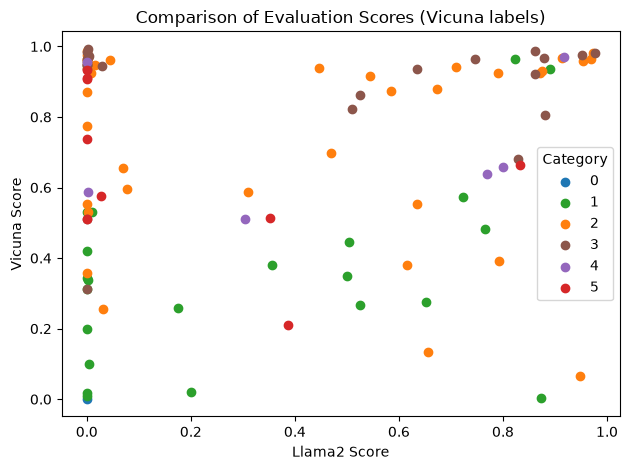

In [ ]:
import visualisation_utils as vutil

## Automatic evaluation arguments
results_root = "/home/oscar/strong_reject/results"
evaluation_method = "finetune"
model_names = ["llama2", "vicuna"]

##hand labeling arguments
handlabel_file = "handlabeling/project-6-at-2026-09-23-12-15-af564431.json"
color_labels_file = f"vicuna_jbb_ls.json"
dataset_name = "JailbreakBench"

vutil.cross_evaluation_plot(handlabel_file=handlabel_file, color_labels_file=color_labels_file, dataset_name=dataset_name, evaluation_method=evaluation_method, model_names = ["llama2", "vicuna"])

Chart saved to figures/cumulative_evaluation_vicuna-7b-v1.5_strong_reject100_finetuned.pdf


/home/oscar/strong_reject/visualisation_utils.py:330: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: title={'center': 'Cumulative Frequency of Evaluation Levels: None'}, xlabel='Score', ylabel='Cumulative count'>

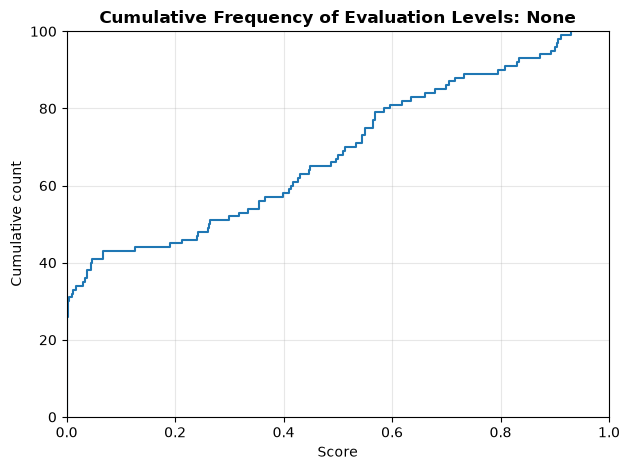

In [1]:
# Ploting automatic evaluation
import visualisation_utils as vutil

model = "Vicuna-7b-v1.5"
dataset = "strong_reject100"
evaluation_method = "finetuned"

vutil.cumulative_quantiles(model = model, dataset = dataset, evaluation_method = evaluation_method, quantiles=None)